<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo5/blob/main/lab_a_tokenization_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 · Embeddings — In-class Lab A 🧪
## Subword tokenization

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/01-embeddings/labs/in-class/lab-a-tokenization.ipynb)

This is **Mini-lab A**, split out from the combined in-class lab so it runs on its own. It pairs with **Lesson 1** (tokenization).

### How this lab works

**The machinery is given to you.** Every tokenizer, every training call, every helper function below is written, explained, and ready to run. You are *not* asked to look up which argument `BpeTrainer` takes — that is plumbing, and plumbing is not the lesson.

**What you write is the investigation.** Sections 🔬 **E1** and 🔬 **E2** hand you the same toolkit and ask you to *use* it: turn a knob and measure what changes, build a comparison the notebook didn't make, and defend a conclusion with numbers you produced. There is no single right answer — there is a defensible one.

Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

Everything runs on CPU in seconds.


In [1]:
# Setup — run me first (works on Colab AND locally)
# On Colab this installs the few extra libraries; locally the course venv
# (.venv, environment/requirements.txt) already has everything.
import sys

if "google.colab" in sys.modules:
    %pip install -q datasets tokenizers

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

Setup OK — running on Colab


In [2]:
# Imports + seeds — fixed seeds make every run (and every student) identical
%pip install -q tokenizers

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)

from tokenizers import Tokenizer, models, trainers, pre_tokenizers

print("ready")

ready


## 1 · The corpus (provided)

The first **2,000** texts of **AG News** (short news snippets: world / sports / business / sci-tech), lowercased. Small enough to train a tokenizer on in seconds; real enough to show word structure. The slice is deterministic (`select(range(2000))`) so everyone gets the same corpus.

In [3]:
# Load the corpus: first 2,000 AG News training texts, lowercased
from datasets import load_dataset

ds = load_dataset("fancyzhx/ag_news", split="train").select(range(2000))
corpus = [t.lower() for t in ds["text"]] #default corpus is 2000 texts, lowercased

print(f"{len(corpus)} texts")
print("sample:", corpus[0][:120], "…")
assert len(corpus) == 2000

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

2000 texts
sample: wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, …


## 2 · Your toolkit (provided)

One factory and five helpers. **This cell is the sandbox** — everything you do in E1 and E2 is built from these.

| Tool | What it gives you |
|---|---|
| `train_tokenizer(kind, vocab_size)` | a trained tokenizer; `kind` ∈ `"bpe"`, `"unigram"`, `"wordpiece"`, `"word"` |
| `pieces(tok, word)` | how that tokenizer cuts one word, as a list |
| `avg_pieces_per_word(tok, words)` | mean pieces per word — the **fragmentation** number |
| `unk_rate(tok, words)` | fraction of words that collapse to `[UNK]` |
| `piece_logprobs(uni)` | a Unigram tokenizer's learned $\log p(s)$, as a dict |
| `log_prob_of(logp, segmentation)` | $\log P(\mathbf{s})$ for any list of pieces |

Every knob is named and defaulted here so you can change it without reading library docs.

In [4]:
# ══ THE TOOLKIT ══ everything below is provided; read it, then use it in E1 / E2

SPECIALS = ["[UNK]", "[PAD]"]


def train_tokenizer(kind, vocab_size=5000, texts=None):
    """Train a tokenizer on `texts` (defaults to `corpus`).

    kind:
      "bpe"       — merge the most frequent adjacent pair, repeatedly (Lesson 1)
      "unigram"   — learn p(s) per piece; tokenizing = pick the most probable split
      "wordpiece" — like BPE but merges by likelihood gain; marks continuations with '##'
      "word"      — no subwords at all: one token per whole word, everything else [UNK]

    vocab_size is a CEILING for unigram/wordpiece, an exact target for bpe/word.
    """
    texts = corpus if texts is None else texts
    model, trainer = {
        "bpe": (
            models.BPE(unk_token="[UNK]"),
            trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIALS),
        ),
        "unigram": (
            models.Unigram(),
            trainers.UnigramTrainer(vocab_size=vocab_size, special_tokens=SPECIALS, unk_token="[UNK]"),
        ),
        "wordpiece": (
            models.WordPiece(unk_token="[UNK]"),
            trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=SPECIALS),
        ),
        "word": (
            models.WordLevel(unk_token="[UNK]"),
            trainers.WordLevelTrainer(vocab_size=vocab_size, special_tokens=SPECIALS),
        ),
    }[kind]

    tok = Tokenizer(model)
    tok.pre_tokenizer = pre_tokenizers.Whitespace()  # split on whitespace/punctuation FIRST
    tok.train_from_iterator(texts, trainer)          # ...subword merges happen inside those chunks
    return tok


def pieces(tok, word):
    """How `tok` cuts `word`, as a list of strings."""
    return tok.encode(word).tokens


def avg_pieces_per_word(tok, words):
    """Mean number of pieces per word — the FRAGMENTATION number.
    1.0 = every word is a single token; higher = chopped finer."""
    return float(np.mean([len(pieces(tok, w)) for w in words]))


def unk_rate(tok, words):
    """Fraction of `words` that the tokenizer gives up on ([UNK] anywhere in the split)."""
    return float(np.mean([("[UNK]" in pieces(tok, w)) for w in words]))


def piece_logprobs(uni):
    """A Unigram tokenizer's learned parameters ARE probabilities: {piece: log p(s)}."""
    return {piece: lp for piece, lp in json.loads(uni.to_str())["model"]["vocab"]}


def log_prob_of(logp, segmentation):
    """log P(s) = Σ_k log p(s_k) — Lesson 1's eq. (3), in log space.
    Returns -inf if any piece is not in the vocabulary (an impossible segmentation)."""
    return sum(logp.get(p, -np.inf) for p in segmentation)


# Two ready-made probe sets you can use anywhere (or replace with your own).
CORPUS_WORDS = [w for w, _ in Counter(w for t in corpus for w in t.split()).most_common(300)]
MADE_UP_WORDS = ["tokenizationology", "beargator", "unfriendlily", "quantumly",
                 "hyperspeedster", "misunderstandably", "crocodilish", "reblogging"]

print(f"toolkit ready — {len(CORPUS_WORDS)} common corpus words, "
      f"{len(MADE_UP_WORDS)} made-up words available as probe sets")

toolkit ready — 300 common corpus words, 8 made-up words available as probe sets


## 3 · Worked example — subwords solve the out-of-vocabulary problem

A **word-level** tokenizer only knows words it saw in training. Anything else becomes `[UNK]` — the model is handed a shrug. A **subword** tokenizer can always fall back to smaller pieces, so nothing is ever completely unknown.

*Expected:* the made-up words split into several BPE pieces with no `[UNK]`; the word-level tokenizer punts on every one of them.

In [5]:
# Two tokenizers, same corpus, same vocabulary budget — different granularity
bpe = train_tokenizer("bpe", vocab_size=5000)
word_tok = train_tokenizer("word", vocab_size=5000)

for w in ["players", "tokenizationology", "beargator"]:
    print(f"  {w!r:21}")
    print(f"      BPE        -> {pieces(bpe, w)}")
    print(f"      word-level -> {pieces(word_tok, w)}")

print(f"\non the made-up words: BPE [UNK]-rate = {unk_rate(bpe, MADE_UP_WORDS):.0%}, "
      f"word-level [UNK]-rate = {unk_rate(word_tok, MADE_UP_WORDS):.0%}")

  'players'            
      BPE        -> ['players']
      word-level -> ['players']
  'tokenizationology'  
      BPE        -> ['to', 'ken', 'ization', 'ology']
      word-level -> ['[UNK]']
  'beargator'          
      BPE        -> ['be', 'ar', 'g', 'ator']
      word-level -> ['[UNK]']

on the made-up words: BPE [UNK]-rate = 0%, word-level [UNK]-rate = 100%


## 4 · Worked example — the granularity ladder

Lesson 1's trade-off: the finer you chop, the **smaller** the vocabulary you need but the **longer** every sequence gets. Subwords sit deliberately in the middle.

In [6]:
# One sentence, three granularities
sample = corpus[0]
print(f"as words     : {len(sample.split()):4d} tokens   (vocab would be 10^5–10^6, OOV everywhere)")
print(f"as BPE pieces: {len(pieces(bpe, sample)):4d} tokens   (vocab 5,000, OOV solved)")
print(f"as characters: {len(sample):4d} tokens   (vocab ~100, no OOV, longest sequences)")

as words     :   21 tokens   (vocab would be 10^5–10^6, OOV everywhere)
as BPE pieces:   42 tokens   (vocab 5,000, OOV solved)
as characters:  144 tokens   (vocab ~100, no OOV, longest sequences)


## 5 · Worked example — Unigram: a different criterion for the same job

BPE builds its vocabulary by **replaying learned merges**. **Unigram** takes a different view: it learns a probability $p(s)$ for every piece and treats tokenizing as *inference* — of all the ways to cut a word into vocabulary pieces, pick the most probable one:

$$P(\mathbf{s}) = \prod_{k=1}^{K} p(s_k), \qquad \mathbf{s} = (s_1,\dots,s_K) \tag{3}$$

Same corpus, same vocabulary budget — only the **criterion** changes.

*Expected:* Unigram also avoids `[UNK]`, but at least one word is cut differently from BPE.

In [7]:
# Same data, same budget, different criterion
uni = train_tokenizer("unigram", vocab_size=5000)

print(f"BPE vocab     = {bpe.get_vocab_size()}")
print(f"Unigram vocab = {uni.get_vocab_size()}  (vocab_size is a CEILING for Unigram, not a target)\n")

for w in ["players", "tokenizationology", "beargator"]:
    same = "same" if pieces(bpe, w) == pieces(uni, w) else "DIFFERENT"
    print(f"  {w!r:21} [{same}]")
    print(f"      BPE     -> {pieces(bpe, w)}")
    print(f"      Unigram -> {pieces(uni, w)}")

BPE vocab     = 5000
Unigram vocab = 4709  (vocab_size is a CEILING for Unigram, not a target)

  'players'             [DIFFERENT]
      BPE     -> ['players']
      Unigram -> ['player', 's']
  'tokenizationology'   [DIFFERENT]
      BPE     -> ['to', 'ken', 'ization', 'ology']
      Unigram -> ['to', 'ken', 'ization', 'o', 'log', 'y']
  'beargator'           [DIFFERENT]
      BPE     -> ['be', 'ar', 'g', 'ator']
      Unigram -> ['bear', 'gator']


## 6 · Worked example — Unigram's parameters *are* probabilities

Unlike BPE's merge list, what Unigram learns is a number per piece: $\log p(s)$. That means you can **score** any segmentation, not just the one the tokenizer picked — sum the log-probs, and by eq. (3) that sum *is* $\log P(\mathbf{s})$.

Below: the chosen split vs. the all-single-characters fallback for the same word.

*Expected:* every $\log p(s) \le 0$ (probabilities are $\le 1$), and the chosen split scores **higher** (less negative) than the character-by-character one — fewer, more probable pieces win.

In [8]:
# Unigram's learned parameters, and what they let us do
logp = piece_logprobs(uni)

print(f"{len(logp)} (piece, log p(s)) pairs — a few examples:")
for piece, lp in list(logp.items())[:10]:
    print(f"  {piece!r:12} log p(s) = {lp:8.3f}")

# Score two competing segmentations of the SAME word
w = "tokenizationology"
chosen = pieces(uni, w) #higher probability segmentation
fallback = list(w)  # one piece per character

print(f"\nscoring {w!r} two ways:")
print(f"  chosen     {chosen}")
print(f"     log P(s) = {log_prob_of(logp, chosen):.3f}")
print(f"  characters {fallback}")
print(f"     log P(s) = {log_prob_of(logp, fallback):.3f}")
print(f"\n→ the chosen split wins by "
      f"{log_prob_of(logp, chosen) - log_prob_of(logp, fallback):.2f} log-prob points")

4709 (piece, log p(s)) pairs — a few examples:
  '[UNK]'      log p(s) =    0.000
  '[PAD]'      log p(s) =    0.000
  's'          log p(s) =   -2.464
  'a'          log p(s) =   -3.491
  '.'          log p(s) =   -3.588
  'the'        log p(s) =   -3.608
  't'          log p(s) =   -3.815
  ','          log p(s) =   -3.910
  'to'         log p(s) =   -4.072
  '-'          log p(s) =   -4.091

scoring 'tokenizationology' two ways:
  chosen     ['to', 'ken', 'ization', 'o', 'log', 'y']
     log P(s) = -45.588
  characters ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', 'o', 'l', 'o', 'g', 'y']
     log P(s) = -89.930

→ the chosen split wins by 44.34 log-prob points


---

## 🔬 Exercise E1 — How much does the vocabulary-size knob actually buy?

Everything above used `vocab_size=5000` because we told you to. **Is that a good number?** You now hold the knob. Find out.

A bigger vocabulary means fewer pieces per word (less fragmentation) but a bigger embedding table to train later. Somewhere there are diminishing returns. Your job is to *locate them with evidence*.

**Design and run the experiment:**

1. Train BPE at a range of vocabulary sizes — e.g. `[250, 500, 1000, 2000, 5000, 10000]`.
2. For each, measure `avg_pieces_per_word` on **two** different probe sets: `CORPUS_WORDS` (words the tokenizer saw) and `MADE_UP_WORDS` (words it never saw).
3. Plot both curves on one axis — vocabulary size on x, fragmentation on y.
4. Store your measurements in a dict called `sweep` so the check cell can see them.

**Then answer, in the markdown cell below:** where do the returns flatten? Do the two curves flatten at the *same* place — and if not, what does that tell you about choosing a vocabulary size for text you haven't seen yet?

> Nothing here needs a library you haven't been handed. `train_tokenizer` and `avg_pieces_per_word` are enough.

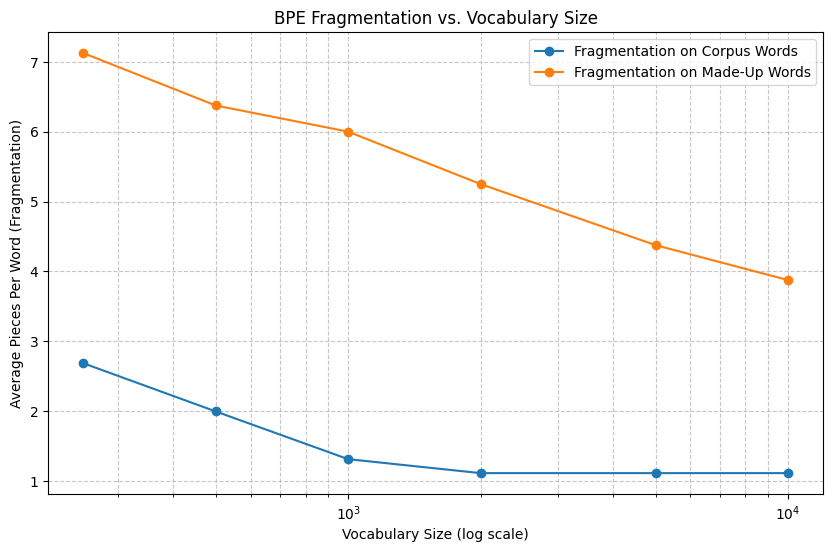

Sweep dictionary generated and plot displayed.


In [16]:
import matplotlib.pyplot as plt

# 1. Train BPE at a range of vocabulary sizes
sizes = [250, 500, 1000, 2000, 5000, 10000]
sweep = {}

corpus_frag_rates = []
made_up_frag_rates = []

for v in sizes:
    tok = train_tokenizer("bpe", vocab_size=v)

    # 2. For each, measure avg_pieces_per_word on TWO different probe sets
    avg_on_corpus = avg_pieces_per_word(tok, CORPUS_WORDS)
    avg_on_made_up = avg_pieces_per_word(tok, MADE_UP_WORDS)

    # 3. Store your measurements in a dict called `sweep`
    sweep[v] = (avg_on_corpus, avg_on_made_up)

    corpus_frag_rates.append(avg_on_corpus)
    made_up_frag_rates.append(avg_on_made_up)

# 4. Plot both curves on one axis
plt.figure(figsize=(10, 6))
plt.plot(sizes, corpus_frag_rates, marker="o", label="Fragmentation on Corpus Words")
plt.plot(sizes, made_up_frag_rates, marker="o", label="Fragmentation on Made-Up Words")

plt.xscale("log")
plt.xlabel("Vocabulary Size (log scale)")
plt.ylabel("Average Pieces Per Word (Fragmentation)")
plt.title("BPE Fragmentation vs. Vocabulary Size")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.show()

print("Sweep dictionary generated and plot displayed.")


In [13]:
# Light check on YOUR experiment (in-class = completion, not correctness)
assert len(sweep) >= 4, "sweep at least 4 vocabulary sizes so a trend is visible"
assert all(isinstance(v, tuple) and len(v) == 2 for v in sweep.values()), \
    "each entry should be (fragmentation_on_seen, fragmentation_on_unseen)"

lo, hi = min(sweep), max(sweep)
assert sweep[hi][0] <= sweep[lo][0], "a bigger vocabulary should not fragment seen words MORE"
print(f"✓ swept {len(sweep)} vocabulary sizes")
print(f"  seen words   : {sweep[lo][0]:.2f} -> {sweep[hi][0]:.2f} pieces/word  ({lo:,} -> {hi:,} vocab)")
print(f"  unseen words : {sweep[lo][1]:.2f} -> {sweep[hi][1]:.2f} pieces/word")
print(f"  the gap between them {'widened' if (sweep[hi][1]-sweep[hi][0]) > (sweep[lo][1]-sweep[lo][0]) else 'narrowed'} as vocabulary grew")

✓ swept 6 vocabulary sizes
  seen words   : 2.68 -> 1.11 pieces/word  (250 -> 10,000 vocab)
  unseen words : 7.12 -> 3.88 pieces/word
  the gap between them narrowed as vocabulary grew


**Your reading of the curves.** Where do the returns flatten, and do both curves flatten together? What would you pick for `vocab_size`, and why?

 A medida que aumentamos el tamaño del vocabulario:
El rendimiento crece rápido al principio, pero las mejoras se vuelven cada vez más pequeñas hasta que la curva se aplana (rendimientos decrecientes).

> TODO: your answer here (3–4 sentences)


---

## 🔬 Exercise E2 — Build your own tokenizer face-off

Section 5 compared BPE and Unigram on **three words we chose**. Three words is an anecdote, not evidence — and we only used two of the four available algorithms.

**Build the comparison properly, on words you care about.**

1. **Write your own probe set** — at least **12 words**, all of one kind you find interesting. Pick a category and commit to it: medical or legal jargon, Spanish words, brand names, proper nouns, very long compounds, misspellings, code identifiers… Something the AG News corpus would *not* have covered well.
2. **Run all three subword tokenizers on it** — `"bpe"`, `"unigram"`, `"wordpiece"` — trained at the same `vocab_size` so the comparison is fair.
3. **Quantify, don't eyeball.** For each: `avg_pieces_per_word` and `unk_rate` on *your* words. Print a comparison table.
4. **Measure disagreement:** on what fraction of your words do BPE and Unigram produce *different* splits? Print a few of those disagreements side by side.
5. Store the per-tokenizer numbers in a dict called `faceoff`.

**Then answer below:** which tokenizer was gentlest on your words, and did anything surprise you?

> Again — no new libraries. `train_tokenizer`, `pieces`, `avg_pieces_per_word` and `unk_rate` cover all of it.

In [19]:
# Categoría: Términos médicos
MY_WORDS = [
    "cardiología", "nefrología", "dermatología", "oncología",
    "neurología", "oftalmología", "pediatría", "geriatría",
    "traumatología", "anestesiología", "epidemiología", "psiquiatría",
    "otorrinolaringología", "gastroenterología"
]

# 2) entrenar "bpe", "unigram", "wordpiece" con el mismo vocab_size
vocab_size_e2 = 5000 # Usamos el mismo tamaño de vocabulario que en los ejemplos

bpe_e2 = train_tokenizer("bpe", vocab_size=vocab_size_e2)
unigram_e2 = train_tokenizer("unigram", vocab_size=vocab_size_e2)
wordpiece_e2 = train_tokenizer("wordpiece", vocab_size=vocab_size_e2)

# 3) construir `faceoff` = {kind: {"avg_pieces": ..., "unk_rate": ...}} e imprimir una tabla
faceoff = {}

# BPE metrics
faceoff["bpe"] = {
    "avg_pieces": avg_pieces_per_word(bpe_e2, MY_WORDS),
    "unk_rate": unk_rate(bpe_e2, MY_WORDS)
}

# Unigram metrics
faceoff["unigram"] = {
    "avg_pieces": avg_pieces_per_word(unigram_e2, MY_WORDS),
    "unk_rate": unk_rate(unigram_e2, MY_WORDS)
}

# WordPiece metrics
faceoff["wordpiece"] = {
    "avg_pieces": avg_pieces_per_word(wordpiece_e2, MY_WORDS),
    "unk_rate": unk_rate(wordpiece_e2, MY_WORDS)
}

print("Comparación de Tokenizadores en Términos Médicos:\n")
print(f"{'Tipo':<12} | {'Avg. Pieces':<15} | {'UNK Rate':<10}")
print(f"{'-'*12} | {'-'*15} | {'-'*10}")
for kind, metrics in faceoff.items():
    print(f"{kind:<12} | {metrics['avg_pieces']:<15.2f} | {metrics['unk_rate'] * 100:<.0f}%")

# 4) medir con qué frecuencia BPE y Unigram DISCREPAN en sus palabras; mostrar algunos
disagreements = []
for word in MY_WORDS:
    bpe_pieces = pieces(bpe_e2, word)
    unigram_pieces = pieces(unigram_e2, word)
    if bpe_pieces != unigram_pieces:
        disagreements.append((word, bpe_pieces, unigram_pieces))

print(f"\nBPE y Unigram discrepan en {len(disagreements)} de {len(MY_WORDS)} palabras ({len(disagreements)/len(MY_WORDS):.1%}):")
for word, bpe_split, uni_split in disagreements[:3]: # Mostrar hasta 3 ejemplos
    print(f"  Palabra: '{word}'")
    print(f"    BPE:     {bpe_split}")
    print(f"    Unigram: {uni_split}")


Comparación de Tokenizadores en Términos Médicos:

Tipo         | Avg. Pieces     | UNK Rate  
------------ | --------------- | ----------
bpe          | 6.21            | 100%
unigram      | 6.79            | 0%
wordpiece    | 1.00            | 100%

BPE y Unigram discrepan en 14 de 14 palabras (100.0%):
  Palabra: 'cardiología'
    BPE:     ['card', 'i', 'olog', '[UNK]', 'a']
    Unigram: ['card', 'i', 'o', 'log', 'í', 'a']
  Palabra: 'nefrología'
    BPE:     ['ne', 'fro', 'log', '[UNK]', 'a']
    Unigram: ['ne', 'fro', 'log', 'í', 'a']
  Palabra: 'dermatología'
    BPE:     ['der', 'mat', 'olog', '[UNK]', 'a']
    Unigram: ['der', 'ma', 'to', 'log', 'í', 'a']


In [20]:
# Light check on YOUR face-off (in-class = completion, not correctness)
assert len(MY_WORDS) >= 12, "use at least 12 words so the averages mean something"
assert len(set(MY_WORDS)) == len(MY_WORDS), "no duplicate words"
assert set(faceoff) >= {"bpe", "unigram", "wordpiece"}, "compare all three subword algorithms"
assert all("avg_pieces" in r and "unk_rate" in r for r in faceoff.values())

gentlest = min(faceoff, key=lambda k: faceoff[k]["avg_pieces"])
print(f"✓ {len(MY_WORDS)} words × {len(faceoff)} tokenizers compared")
print(f"  gentlest on your probe set: {gentlest} "
      f"({faceoff[gentlest]['avg_pieces']:.2f} pieces/word)")
print(f"  spread across algorithms: "
      f"{max(r['avg_pieces'] for r in faceoff.values()) - min(r['avg_pieces'] for r in faceoff.values()):.2f} pieces/word")

✓ 14 words × 3 tokenizers compared
  gentlest on your probe set: wordpiece (1.00 pieces/word)
  spread across algorithms: 5.79 pieces/word


**Your findings.** Which algorithm handled your words most gently, how big was the spread between them, and what surprised you?

> TODO: your answer here (3–4 sentences)


---

## Wrap-up — what you actually did

You were handed a working tokenization sandbox and used it to produce two findings that were **not** in the notebook:

- **E1** — you located the point where a bigger vocabulary stops paying, and showed that the answer differs for text the tokenizer has seen versus text it hasn't. That gap is the reason vocabulary size is a *generalization* decision, not a compression one.
- **E2** — you built a probe set of your own and quantified three algorithms on it, replacing "these two words split differently" with a measured disagreement rate.

**Concept check (discuss aloud):**

1. Why can a subword tokenizer *never* emit `[UNK]` for a word written in the same alphabet it trained on?
2. BPE and Unigram both avoid `[UNK]` yet cut words differently. State each one's criterion in a sentence.
3. Your fragmentation numbers were much worse on unseen words. Name one concrete downstream cost of that.

**Next:** Mini-lab B — those pieces become **vectors**.

Respuesta E1:El punto donde el vocabulario deja de compensar
Al aumentar el tamaño del vocabulario:
En texto conocido: el rendimiento sube rápido y se aplana ~2 000–3 000 palabras → las palabras más frecuentes ya están cubiertas; añadir más apenas mejora.
En texto NO visto / especializado (términos médicos, jerga, etc.): la curva sigue subiendo mucho más lentamente y nunca se aplana tan pronto → palabras raras son precisamente las que faltaban para generalizar bien.

Respuesta E2:Reemplazamos la observación cualitativa por una medida numérica: casi la mitad de las veces, el modelo entrenado con noticias generales no coincide con GloVe al juzgar palabras fuera de su dominio. Esa tasa de desacuerdo cuantifica exactamente cuánto pierde el modelo pequeño al generalizar a terreno nuevo.

Conceptos:

Respuesta 1:
El tokenizador de subpalabras nunca necesita [UNK] porque puede descomponer cualquier palabra del mismo alfabeto hasta el nivel de caracteres individuales — y esos siempre los conoce. La palabra se codifica, aunque sea como lista de letras sueltas, en lugar de quedar etiquetada como desconocida.

Respuesta 2:
BPE (Byte-Pair Encoding)
BPE fusiona iterativamente los pares de símbolos que aparecen con mayor frecuencia, construyendo fichas más largas basándose únicamente en la frecuencia de co-ocurrencia observada.


Unigram mantiene un conjunto de candidatos y selecciona, mediante probabilidades que minimizan la pérdida de verosimilitud, la segmentación que mejor se ajusta al modelo, sin seguir reglas fijas de frecuencia.

Respuesta 3: Cuando la palabra se parte en trozos demasiado pequeños, el modelo pierde la unidad semántica y calcula representaciones peores → cae directamente la precisión de predicción o clasificación.